# Security assets from VHDL, with an audit trail

**NEORV32: the 41 modules that have a manual reference in the LAsset dataset**

This notebook runs the final version of my pipeline, from raw VHDL to a list of security assets. Then it traces every
listed asset back to the code.

LAsset (arXiv 2601.02624, DATE 2026) asks an LLM to name the security assets of an RTL module and scores the list
against a manual reference. It does not record *why* the model listed an element. My addition is an evidence layer
that is built by code, in front of the LLM and behind it:

| step | what it is | built by |
|---|---|---|
| 1 occurrence profiles | every place a port or signal name appears gets a number (its **occurrence ID**), its line, and the VHDL structure around it | code (tree-sitter) |
| 2 relationship map | typed records between elements, such as `ctrl.lock GATES ctrl.enable`, each anchored to the occurrence IDs where it holds | code |
| 3 checks | self-tests against hand-read lines, byte-identical rebuilds, line integrity, accuracy against a gold sample | code |
| 4 generation | the final prompt asks the model to cite, for every asset, the occurrence ID and the record its decision rests on | gpt-5.4 |
| 5 audit trail | listed asset → occurrence ID → source line → relationship record → is the citation true? | code |

The audit trail is then used on a question that accuracy numbers cannot answer: **why did precision stop rising,
across two months of prompt changes?**

**How to read it.** Every number is printed by a code cell in this notebook. The prose holds no figures of its own.
Text marked *Reading* is my interpretation, not a measurement.

**How to run it.** `pip install -r requirements.txt`, then run all cells. With `RUN_API = False` nothing calls an API
and the notebook runs in a few minutes. Held-out generation is **pending**: my OpenAI credits ran out before it ran.
With a key in `API.env` and `RUN_API = True`, the generation cell runs it, and the analysis cells pick up the
held-out runs on their own.

In [1]:
RUN_API = False   # True: held-out generation (26 modules x 3 runs on gpt-5.4) and the fault reporter's LLM step

import sys, json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "final")
import final_pipeline as FP

ns = FP.setup()          # moves to the repo root, loads the pipeline modules, checks the tree-sitter VHDL grammar
mods = FP.modules(ns.ea)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)
print(f"tuning set:   {len(mods['tuning']):>2} modules, {mods['entries']['tuning']} reference entries")
print(f"held-out set: {len(mods['heldout']):>2} modules, {mods['entries']['heldout']} reference entries")

tuning set:   15 modules, 111 reference entries
held-out set: 26 modules, 189 reference entries


## 1. The 41 modules

The manual reference (`ground_truth/manual_gt_neorv32.json`, from the LAsset dataset) lists the security assets of 41
NEORV32 modules. One reference entry is one asset of one module.

- **Tuning set, 15 modules.** Every prompt change in the logs was scored here.
- **Held-out set, 26 modules.** The prompt-optimization loop that produced the final prompt never saw these modules.
  Earlier versions were checked on them, so they are held out from the final prompt's tuning, not unseen by me.

In [2]:
short = lambda ms: ", ".join(m.replace("neorv32_", "") for m in ms)
pd.DataFrame({"modules": [short(mods["tuning"]), short(mods["heldout"])],
              "count": [len(mods["tuning"]), len(mods["heldout"])],
              "reference entries": [mods["entries"]["tuning"], mods["entries"]["heldout"]]},
             index=["tuning", "held-out"])

,modules,count,reference entries
tuning,"bus, cache, cpu, cpu_cp_cfu, cpu_cp_muldiv, cpu_pmp, debug_dtm, hwspinlock, imem, spi, sys, trng...",15,111
held-out,"cpu_alu, cpu_control, cpu_counters, cpu_cp_bitmanip, cpu_cp_cond, cpu_cp_crypto, cpu_cp_fpu, cpu...",26,189


## 2. Occurrence profiles

An **element** is a port or a signal; a record field such as `ctrl.lock` is an element of its own. An **occurrence** is
one place the element's name appears in the module. Each occurrence gets:

- an **occurrence ID** (1, 2, 3, ... in source order, per element). The generator cites these IDs.
- its **line** and the line's text.
- its **Context**: the enclosing VHDL constructs, innermost first (process, if, case, ...), from the tree-sitter parse.
- its **SITE tags**: the role of the name on that line, for example the target of an assignment (`LHS_PROC`), an
  operand on the right-hand side (`RHS_OPERAND`), or a condition (`IF_COND`).

The cell below rebuilds everything from the VHDL in `RTL_data/` and `RTL_heldout/`: closed sets (the fixed list of
elements per module, found by regex), occurrence profiles, relationship maps and the generator's inputs. It writes
them under `final/`.

In [3]:
built = FP.build_all(ns, mods)
print(f"built in {built['seconds']} s")
pd.DataFrame(FP.profile_stats(built, mods)).T

built in 42.2 s


,modules,elements,occurrences,relationship records
tuning,15,1641,5760,2834
heldout,26,1713,11997,5934


**Example: `ctrl.lock` in the watchdog timer (`neorv32_wdt`).** Software sets the lock bit; after that the
watchdog's configuration cannot be changed until a reset. Its occurrence profile:

In [4]:
ex = FP.example_element(built, "neorv32_wdt", "neorv32_wdt", "ctrl.lock")
pd.DataFrame(ex["profile"])

,Occurrence ID,Occurrence Lines,Line Text,Context,SITE Tagged
0,1,54,signal ctrl : ctrl_t;,declarative part 35-65 in architecture 32-182,[DECL_FIELD]
1,2,76,ctrl.lock <= '0';,then branch 73-80 in if 73-116 in process bus_access 71-117 in architecture 32-182,[LHS_PROC]
2,3,93,if (ctrl.lock = '0') then,then branch 93-97 in if 93-100 in then branch 92-100 in if 92-107 in then branch 91-107 in if 91...,[IF_COND]
3,4,95,ctrl.lock <= bus_req_i.data(ctrl_lock_c) and ctrl.enable;,then branch 93-97 in if 93-100 in then branch 92-100 in if 92-107 in then branch 91-107 in if 91...,[LHS_PROC]
4,5,110,bus_rsp_o.data(ctrl_lock_c) <= ctrl.lock;,else branch 108-113 in if 91-114 in then branch 90-114 in if 90-115 in elsif branch 81-115 in if...,[DIRR_ASS]


## 3. Relationship map

Each record links an element to another element at the occurrence where the link holds. The types come in pairs:
the element that acts (left) and the element acted on (right).

| type (acts) | type (acted on) | meaning |
|---|---|---|
| CARRIES | COPIES | the value is copied unchanged (the whole right-hand side) |
| SOURCES | DERIVES_FROM | the value is an operand of a computation, a slice or an argument |
| GATES | GATED_BY | an `if` or `when` condition decides whether the other element is assigned |
| SELECTS | SELECTED_BY | a `case` selector or a run-time index decides which value is assigned |
| CONSTRAINS | CONSTRAINED_BY | a comparison with the other element |
| SEQUENCES | CLOCKED_BY | the clock edge that times the update |
| RESETS | RESET_BY | the reset that forces the reset value |

`storage` says whether the element holds its value across clock cycles (`edge`) or is combinational (`comb`).
The records for `ctrl.lock`:

In [5]:
print("storage:", ex["storage"])
pd.DataFrame([{"type": r["type"], "targets": ", ".join(r["targets"]), "at occurrence": r["at"], "condition": r.get("guard", "")}
              for r in ex["records"]])

storage: edge


,type,targets,at occurrence,condition
0,GATES,"ctrl.enable, ctrl.lock, ctrl.strict, ctrl.timeout",[3],ctrl.lock = '0'
1,GATES,reset_force,[3],not (ctrl.lock = '0')
2,CARRIES,bus_rsp_o.data,[5],
3,CLOCKED_BY,clk_i,[4],
4,RESET_BY,rstn_sys_i,[2],
5,GATED_BY,bus_req_i.addr,[4],bus_req_i.addr(2) = '0'
6,GATED_BY,"bus_req_i.data, ctrl.enable",[4],bus_req_i.data(ctrl_lock_c) and ctrl.enable
7,GATED_BY,bus_req_i.rw,[4],bus_req_i.rw = '1'
8,GATED_BY,bus_req_i.stb,[4],bus_req_i.stb = '1'
9,GATED_BY,ctrl.lock,[4],ctrl.lock = '0'


Across all 41 modules, by type:

In [6]:
types = Counter()
for split in ("tuning", "heldout"):
    for m in mods[split]:
        d = json.loads((built["maps"][split] / f"{m}.json").read_text(encoding="utf-8"))
        types.update(r["type"] for a in ("ports", "signals") for e in d[a] for r in e["relationship"])
pd.Series(types).sort_values(ascending=False).to_frame("records")

,records
GATED_BY,1984
GATES,1604
SOURCES,931
SELECTED_BY,766
DERIVES_FROM,717
CLOCKED_BY,566
RESET_BY,520
COPIES,499
CARRIES,499
SELECTS,257


**What the generator reads.** For each module the generator gets one text: the numbered RTL, then the map with the
occurrence IDs and the line of each record. This is the part of `neorv32_wdt`'s input that describes `ctrl.lock`:

In [7]:
text = (built["traced_inputs"] / "tuning" / "neorv32_wdt.txt").read_text(encoding="utf-8").splitlines()
start = next(i for i, l in enumerate(text) if l.startswith("SIGNAL ") and '"name":"ctrl.lock"' in l)
end = next(i for i in range(start + 1, len(text)) if text[i].startswith(("SIGNAL ", "PORT ")))
print("\n".join(text[start:end]))

SIGNAL {"name":"ctrl.lock","entity":"neorv32_wdt","kind":"register","handling":["ORIGINATES","CONSUMES"],"storage":"edge"}
    {"occurrences":[{"id":1,"line":54},{"id":2,"line":76},{"id":3,"line":93},{"id":4,"line":95},{"id":5,"line":110}]}
    {"constant_drivers":[{"at":2,"value":"'0'","lines":[76]}]}
    {"type":"GATES","at":[3],"guard":"ctrl.lock = '0'","lines":[93],"targets":["ctrl.enable","ctrl.lock","ctrl.strict","ctrl.timeout"]}
    {"type":"GATES","at":[3],"guard":"not (ctrl.lock = '0')","lines":[93],"targets":["reset_force"]}
    {"type":"CARRIES","at":[5],"lines":[110],"targets":["bus_rsp_o.data"]}
    {"type":"CLOCKED_BY","at":[4],"lines":[95],"targets":["clk_i"]}
    {"type":"RESET_BY","at":[2],"lines":[76],"targets":["rstn_sys_i"]}
    {"type":"GATED_BY","at":[4],"guard":"bus_req_i.addr(2) = '0'","lines":[95],"targets":["bus_req_i.addr"]}
    {"type":"GATED_BY","at":[4],"guard":"bus_req_i.data(ctrl_lock_c) and ctrl.enable","lines":[95],"targets":["bus_req_i.data","ctrl.ena

## 4. Is the map correct?

Four checks, from narrow to broad.

1. **Self-tests.** Each pipeline module carries hand-read facts from real lines of this corpus and asserts them.
2. **Reproducibility.** The rebuild above must be byte-identical to the maps and inputs the experiments used.
3. **Line integrity.** Every occurrence in every generator input must sit on a numbered line that names the element.
4. **Accuracy against a gold sample.** A stratified sample of occurrences from the tuning modules, with the records
   they should carry. The gold was written by an LLM in two passes and adjudicated; no person wrote it. So this is a
   consistency check against a second method, not a human ground truth.

In [8]:
pd.Series(FP.self_tests(ns, built)).to_frame("passes")

,passes
"code_pairs_v2 (relationship records, hand-read cases)",True
closed sets (build_heldout_code_map.selftest_closed),True
"held-out gpio map, 9 hand-read facts",True
"traced inputs (hand-read lines, flow, connection directions)",True
trace_check (citation checker),True
code SITE tagger (75 hand-read occurrences),True


In [9]:
for k, v in FP.reproducibility(built, mods).items():
    print(f"{k}: {v}")
for split, v in FP.line_integrity(ns, built, mods).items():
    print(f"line integrity, {split}: {v} occurrences on a line that names the element")

maps byte-identical to the stored maps: 43/43
traced inputs byte-identical to assetgen_meta/traced_inputs_v2: 41/41
line integrity, tuning: 5760/5760 occurrences on a line that names the element
line integrity, heldout: 11997/11997 occurrences on a line that names the element


In [10]:
acc = FP.relation_accuracy(built)
pd.Series({k: str(v) for k, v in acc.items()}).to_frame("relationship records vs gold (tuning maps)")

,relationship records vs gold (tuning maps)
occurrences,120
gold records,212
typed precision,0.988
precision 95% CI,"(0.969, 1.0)"
typed recall,0.988
recall 95% CI,"(0.969, 1.0)"
target-only precision,1.0
target-only recall,1.0
correct / wrong / missed (unweighted),210 / 2 / 2


*Reading.* Precision is the share of records the map gives that the gold also has. Recall is the share of gold
records the map gives. Both are weighted by stratum, and the brackets are 95% bootstrap intervals. The held-out
maps have no accuracy measurement. For them the evidence is the self-test on hand-read `gpio` facts and the line
integrity count above.

## 5. Asset generation with the final prompt

The final prompt is `assetgen_meta/prompt_opt/v1/exec_prompt.txt`, pinned by its hash. The cell checks the pin and the
prompt checks: no module or element name of this corpus appears in it, and it gives no numeric hints such as "list at
most N". The executor is gpt-5.4, with three runs per module.

In [11]:
prompt = FP.final_prompt(ns)
print(f"version {FP.FINAL_VERSION}, sha12 {FP.FINAL_SHA}, {len(prompt)} characters; pin and prompt checks pass")
for split, rows in FP.generation_status(ns, mods).items():
    print(split, *rows, sep="\n  ")

version m7e194es0opt1_g54, sha12 802ee9a90d41, 180670 characters; pin and prompt checks pass
tuning
  assets_tuning18_m7e194es0opt1_g54_r0: 15/15 modules
  assets_tuning18_m7e194es0opt1_g54_r1: 15/15 modules
  assets_tuning18_m7e194es0opt1_g54_r2: 15/15 modules
heldout
  assets_heldout26_m7e194es0opt1_g54_r0: 0/26 modules
  assets_heldout26_m7e194es0opt1_g54_r1: 0/26 modules
  assets_heldout26_m7e194es0opt1_g54_r2: 0/26 modules


In [12]:
client = None
if RUN_API:
    from dotenv import load_dotenv
    from openai import OpenAI
    load_dotenv("API.env")
    client = OpenAI()
    FP.generate(ns, mods, built, client, splits=("heldout",))   # resumes: modules already on disk are skipped
else:
    print("Held-out generation is pending: it needs OpenAI credits. Set RUN_API = True and run the notebook again.")

Held-out generation is pending: it needs OpenAI credits. Set RUN_API = True and run the notebook again.


## 6. Scores

Strict scoring (`eval_assets.score`): a listed asset counts as a hit only if it matches a reference entry of the same
module by name. **Precision** = hits / assets listed. **Recall** = reference entries found / reference entries.

The LAsset rows are LAsset's published output lists, scored here with the same scorer against the same reference.
They are not runs of mine. Their spec+RTL configuration also reads the module's specification. My pipeline reads
only the RTL, so the RTL-only row is the like-for-like one.

In [13]:
sc = FP.scores(ns, mods)
rows = []
for split, s in sc.items():
    for r in s["runs"]:
        rows.append({"split": split, "list": f"final prompt, run {r['run'][-2:]}", **{k: r[k] for k in ("P", "R", "TP", "FP", "FN")}})
    if s["runs"]:
        rows.append({"split": split, "list": f"final prompt, mean of {len(s['runs'])} runs",
                     "P": round(sum(r["P"] for r in s["runs"]) / len(s["runs"]), 3),
                     "R": round(sum(r["R"] for r in s["runs"]) / len(s["runs"]), 3)})
    else:
        rows.append({"split": split, "list": "final prompt: pending (no complete run)"})
    for name, (p, r) in s["lasset"].items():
        rows.append({"split": split, "list": name, "P": p, "R": r})
pd.DataFrame(rows, dtype=object).set_index(["split", "list"]).fillna("")

P      R  TP   FP  FN
split   list                                                              
tuning  final prompt, run r0                     0.418  0.784  87  121  24
        final prompt, run r1                     0.385  0.829  92  147  19
        final prompt, run r2                     0.418  0.847  94  131  17
        final prompt, mean of 3 runs             0.407   0.82             
        LAsset spec+RTL initial                  0.737   0.91             
        LAsset RTL-only initial                   0.68  0.748             
heldout final prompt: pending (no complete run)                           
        LAsset spec+RTL initial                  0.734  0.862             
        LAsset RTL-only initial                   0.73  0.757

## 7. The audit trail

Each listed asset gives one row of the ledger: the element, whether it is a hit (TP) or a false positive (FP) against
the reference, the role the model gave it, the **occurrence ID** it cited, that occurrence's line and text, the
relationship record it cited, and whether the citation is true. `trace_check` decides the last column against the
map, without an LLM. `verified`: the occurrence exists, sits on that line, and carries that record. `map gap
claimed`: the model cited the occurrence but said the map lacks the record it needed; only the occurrence is checked.

In [14]:
audit = pd.DataFrame(FP.audit_rows(ns, "tuning", mods))
print(f"{len(audit)} listed assets across {audit['run'].nunique()} complete tuning runs")
pd.crosstab(audit["citation"], audit["label"], margins=True)

672 listed assets across 3 complete tuning runs


label,FP,TP,All
citation,,,
map gap claimed,14,2,16
verified,385,271,656
All,399,273,672


One module, one run, the whole list: the watchdog timer, run `r0`.

In [15]:
cols = ["element", "label", "role", "occurrence", "line", "RTL line", "cited edge", "citation"]
audit[(audit["module"] == "wdt") & (audit["run"] == "r0")][cols].reset_index(drop=True)

,element,label,role,occurrence,line,RTL line,cited edge,citation
0,ctrl.enable,TP,stores,3,94,ctrl.enable <= bus_req_i.data(ctrl_enable_c);,CLOCKED_BY clk_i,verified
1,clkgen_en_o,TP,exit port,2,140,clkgen_en_o <= ctrl.enable;,COPIES ctrl.enable,verified
2,ctrl.lock,TP,stores,4,95,ctrl.lock <= bus_req_i.data(ctrl_lock_c) and ctrl.enable;,CLOCKED_BY clk_i,verified
3,ctrl.strict,FP,stores,3,96,ctrl.strict <= bus_req_i.data(ctrl_strict_c);,CLOCKED_BY clk_i,verified
4,ctrl.timeout,TP,stores,3,97,ctrl.timeout <= bus_req_i.data(ctrl_timeout_msb_c downto ctrl_timeout_lsb_c);,CLOCKED_BY clk_i,verified
5,cnt_started,FP,stores,4,130,cnt_started <= ctrl.enable and (cnt_started or prsc_tick);,CLOCKED_BY clk_i,verified
6,cnt,TP,stores,4,134,cnt <= std_ulogic_vector(unsigned(cnt) + 1);,CLOCKED_BY clk_i,verified
7,reset_wdt,TP,stores,4,103,reset_wdt <= '1';,CLOCKED_BY clk_i,verified
8,reset_force,FP,stores,4,99,reset_force <= '1';,CLOCKED_BY clk_i,verified
9,hw_rst_timeout,FP,stores,3,155,hw_rst_timeout <= ctrl.enable and cnt_timeout and prsc_tick;,CLOCKED_BY clk_i,verified


A `verified` citation shows that the cited fact is true. It does not show that the fact makes the element an asset.
In the table above, every element in the role "stores" cites its clock edge, which every register has. Across all
tuning runs, the record type each listed asset cites:

In [16]:
edge_type = audit["cited edge"].fillna("").map(lambda e: e.split()[0] if e else "(none: map gap claimed)")
t = pd.crosstab(edge_type, audit["label"])
t["All"] = t.sum(axis=1)
t.sort_values("All", ascending=False).rename_axis("cited record type")

label,FP,TP,All
cited record type,,,
CLOCKED_BY,234,106,340
DERIVES_FROM,45,33,78
GATED_BY,36,41,77
COPIES,19,21,40
SOURCES,6,28,34
SELECTED_BY,21,7,28
GATES,15,6,21
CARRIES,3,15,18
(none: map gap claimed),14,2,16


## 8. Why precision stops rising: what the occurrence evidence says

The convergence plot in section 10 shows precision moving within a narrow band, across many prompt versions and
several executors. The ledger lets us ask what separates a hit from a false positive *at the level of the code evidence*.
Each listed asset gets a **relationship profile**: its kind (port or signal), its storage, and the classes of records
it carries, such as "controlled ← input port" or "data → output port". Then we measure four things.

1. **Are the false positives hallucinations?** If FP citations were mostly false, a stricter evidence rule would remove them.
2. **Do hits and false positives carry the same kinds of relationships?**
3. **Can a profile tell them apart on a module the rule has not seen?** Fit on 14 modules, test on the 15th, for each
   module in turn (leave one module out).
4. **Minimal pairs.** The same profile, the same kind of verified citation; the reference lists one and not the other.

In [17]:
ev = FP.precision_cap_evidence(ns, mods, client=client)
pd.Series({k: str(v) for k, v in ev["headline"].items()}).to_frame("final prompt, gpt-5.4, tuning runs")

,"final prompt, gpt-5.4, tuning runs"
listed,672
hits,273
false positives,399
relationship classes on both hits and FPs,21/21
FPs with exactly a hit's profile,0.163
"AUC hit vs FP, in-sample",0.776
"AUC hit vs FP, leave one module out",0.644
FP citations verified,0.965
hit citations verified,0.993
FPs in concepts with no reference element,0.594


How alike are the profiles? The reporter clusters the listed assets by profile at four levels of coarseness (cut 0 =
identical profiles only). For each level: the share of false positives that sit in a cluster that also holds a hit.

In [18]:
pd.DataFrame(ev["fault"]["overlap_class"])[["cut", "clusters", "fp_in_mixed", "fp_in_mixed_share"]].rename(
    columns={"fp_in_mixed": "FPs in a cluster with a hit", "fp_in_mixed_share": "share of FPs"})

,cut,clusters,FPs in a cluster with a hit,share of FPs
0,0.00,141,65,0.163
1,0.20,88,186,0.466
2,0.35,44,325,0.815
3,0.50,19,371,0.930


At the finest grain, most false positives have a profile that no hit has. That is why a rule can look good when it
is fitted and tested on the same modules. The question is whether those fine differences carry over to a module the
rule has not seen. First, the relationship classes one by one:

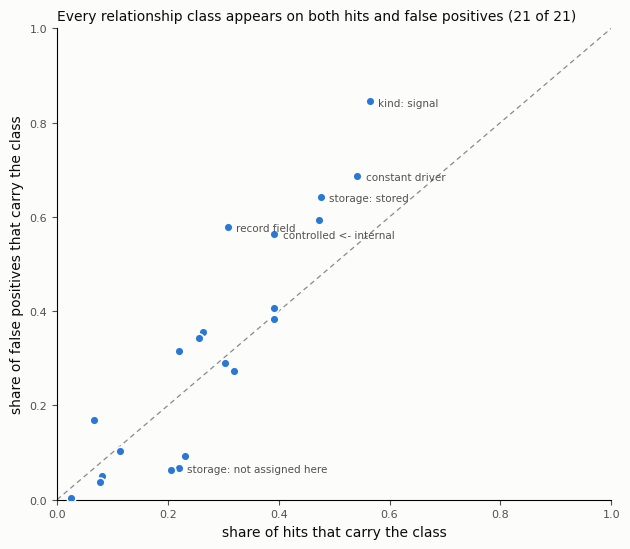

,hits_with,hits_share,fp_with,fp_share
token,,,,
kind: signal,154,0.564,337,0.845
constant driver,148,0.542,274,0.687
storage: stored,130,0.476,256,0.642
reset,129,0.473,237,0.594
controlled <- internal,107,0.392,225,0.564
record field,84,0.308,231,0.579
controlled <- input port,107,0.392,162,0.406
control -> internal,107,0.392,153,0.383
data <- internal,72,0.264,142,0.356


In [19]:
tok = pd.DataFrame(ev["fault"]["token_table_class"]).set_index("token")
fig, ax = plt.subplots(figsize=(6.4, 5.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot([0, 1], [0, 1], color="#8a8984", lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.scatter(tok["hits_share"], tok["fp_share"], s=40, color="#2a78d6", edgecolors="#fcfcfb", linewidths=1.2, zorder=3)
gap = (tok["fp_share"] - tok["hits_share"]).abs().sort_values(ascending=False)
for name in list(gap.index[:6]):
    x, y = tok.loc[name, "hits_share"], tok.loc[name, "fp_share"]
    ax.annotate(name, (x, y), xytext=(6, -3), textcoords="offset points", fontsize=7.5, color="#52514e")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("share of hits that carry the class", color="#0b0b0b")
ax.set_ylabel("share of false positives that carry the class", color="#0b0b0b")
ax.set_title(f"Every relationship class appears on both hits and false positives "
             f"({int(tok['both'].sum())} of {len(tok)})", fontsize=10, loc="left", color="#0b0b0b")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors="#52514e", labelsize=8)
plt.tight_layout(); plt.show()
tok[["hits_with", "hits_share", "fp_with", "fp_share"]]

Points on the dashed line are classes that hits and false positives carry equally often. Above the line: more common
among false positives. Below: more common among hits. The labelled points are the six classes furthest from the line. Next: can those differences be used as a rule on unseen modules?

In [20]:
f, d = ev["fault"], ev["diagnosis"]
sep = f["separability_class"]["pooled"]
tog = f["code_rules_together"]
lomo = d["D3b"]["levels"][1]["leave_one_module_out"]["P@R>=0.7"]
ins = d["D3b"]["levels"][1]["in_sample"]["P@R>=0.7"]
rows = [
    {"measure": "hit vs FP from the profile: AUC (logistic)", "fitted and tested on the same modules": sep["logistic_in_sample_auc"],
     "tested on a module left out": sep["logistic_leave_one_module_out_auc"]},
    {"measure": "rank the listed assets by profile, keep recall >= 0.7: precision", "fitted and tested on the same modules": ins["P"],
     "tested on a module left out": lomo["P"]},
    {"measure": f"all {tog['all_listed']['rules']} code rules found by the reporter: precision / recall after",
     "fitted and tested on the same modules": f"{tog['all_listed']['after']['P']} / {tog['all_listed']['after']['R']}",
     "tested on a module left out": "held-out runs pending" if not tog.get("transfer")
        else f"{tog['transfer']['after']['P']} / {tog['transfer']['after']['R']}"},
    {"measure": "the list as the model gave it: precision / recall", "fitted and tested on the same modules":
        f"{tog['all_listed']['before']['P']} / {tog['all_listed']['before']['R']}", "tested on a module left out": ""},
]
pd.DataFrame(rows).set_index("measure")

,fitted and tested on the same modules,tested on a module left out
measure,,
hit vs FP from the profile: AUC (logistic),0.776,0.644
"rank the listed assets by profile, keep recall >= 0.7: precision",0.433,0.407
all 30 code rules found by the reporter: precision / recall after,0.718 / 0.529,held-out runs pending
the list as the model gave it: precision / recall,0.406 / 0.82,


An AUC of 0.5 means no separation and 1.0 means perfect separation. The code rules are fitted on the reference labels
of these same runs. So their in-sample row is an upper bound, not a usable filter: a rule fitted to the reference is
a convention of the reference, not a security argument.

**Minimal pairs.** Each row is a profile shared by a hit and a false positive. Both citations are checked by code.

In [21]:
pairs = []
for p in d["D4"]:
    for side in ("TP", "FP"):
        x = p[side]
        pairs.append({"profile": p["signature"], "hits / FPs with it": f"{p['TP_count']} / {p['FP_count']}", "side": side,
                      "module": x["module"], "element": x["element"], "occurrence": x["occurrence"], "line": x["line"],
                      "RTL line": x["rtl"], "cited edge": x["edge"], "citation": x["status"]})
pd.DataFrame(pairs).set_index(["profile", "hits / FPs with it", "side"])

module           element  occurrence  line  \
profile                                                                                              hits / FPs with it side                                                      
port-in, not assigned here; controls another element, used here, GATES                               4 / 9              TP       cpu_cp_cfu           start_i           2   204   
                                                                                                                        FP            cache             clr_i           2   380   
port-out, comb; COPIES                                                                               18 / 9             TP             trng            data_o           2   366   
                                                                                                                        FP              spi         spi_clk_o           2   344   
signal field, stored; controls another element, carries data into an output, written from an inpu... 3 / 9              TP              wdt       ctrl.enable           3    94   
                                                                                                                        FP              spi    ctrl.highspeed           3   145   
signal field, comb; controls another element, used here, is gated, GATED_BY, GATES                   6 / 7              TP    cpu_cp_muldiv         div.start           2   155   
                                                                                                                        FP        debug_dtm  dr_trigger.valid           2   161   
port-in, not assigned here; used here, carries data inward, SOURCES                                  24 / 6             TP              cpu             mei_i           2   276   
                                                                                                                        FP            cache           wdata_i           2   414   
signal, stored; updates itself, controls another element, used here, is gated, is reset, CLOCKED_... 3 / 3              TP              bus             state           7   927   
                                                                                                                        FP        debug_dtm    tap_ctrl_state           4   123   

                                                                                                                                                                                                                         RTL line  \
profile                                                                                              hits / FPs with it side                                                                                                        
port-in, not assigned here; controls another element, used here, GATES                               4 / 9              TP                                                       if (start_i = '1') and (rtype_i = r3type_c) then   
                                                                                                                        FP                                                                                  if (clr_i = '1') then   
port-out, comb; COPIES                                                                               18 / 9             TP                                                                                data_o  <= sample_sreg;   
                                                                                                                        FP                                                                           spi_clk_o <= rtx_engine.sck;   
signal field, stored; controls another element, carries data into an output, written from an inpu... 3 / 9              TP                                                         ctrl.enable  <= bus_req_i.data(ctrl_enable_c);   
                       

In [22]:
h = ev["headline"]
cap = (f"Of the {h['false positives']} false positives, {h['FP citations verified']:.1%} cite a true occurrence and record "
       f"(hits: {h['hit citations verified']:.1%}). {h['relationship classes on both hits and FPs']} relationship classes "
       f"occur on both. A profile separates hits from FPs with AUC {h['AUC hit vs FP, in-sample']} in-sample but "
       f"{h['AUC hit vs FP, leave one module out']} on a module it has not seen. {h['FPs in concepts with no reference element']:.1%} "
       f"of the FPs fall in a concept (a group of related elements) where the reference lists nothing in that module.")
print(cap)

Of the 399 false positives, 96.5% cite a true occurrence and record (hits: 99.3%). 21/21 relationship classes occur on both. A profile separates hits from FPs with AUC 0.776 in-sample but 0.644 on a module it has not seen. 59.4% of the FPs fall in a concept (a group of related elements) where the reference lists nothing in that module.


*Reading (my interpretation of the measurements above, not a measurement).* The false positives are not
hallucinations. Nearly all cite real code with a correct relationship, at about the rate the hits do, and the
record they cite is often one that every register carries. Every relationship class occurs on both hits and false
positives. Their shares differ, and so do the fine-grained profiles, but those differences weaken on a module the
rule has not seen. In the minimal pairs, the code evidence is the same and only the reference's choice differs.

This **may explain** the plateau. A general prompt rule can only speak about the code: its relationships, storage,
ports and roles. What separates a listed element from an unlisted one is largely not in that structure. It lies in
which of several defensible elements the reference chose to list in each module. If so, prompt wording cannot raise
precision much further, and more structure in the input will not either. That matches the relation-map experiments:
traced inputs left precision where it was.

**What would falsify this.** The code rules above were found on the tuning runs. Once the held-out runs exist
(`RUN_API = True`), the reporter tests the same rules on them unchanged (the "tested on a module left out" cell of
the rules row). If those rules raise held-out precision substantially without a large recall loss, the separation
*is* structural and general, and this explanation is wrong.

The full reports are in `final/fp_diagnosis/final_gpt54_tuning.md` and `final/fault_report/final_gpt54_tuning/report.md`.

## 9. The evidence layer on LAsset's own list

Can the map judge someone else's list? I ran the same occurrence evidence over LAsset's published RTL-only list for
the 26 held-out modules. The hypotheses, decision rules and file hashes were written before the layer was run on
the held-out set: `assetgen_meta/lasset_layer/PREREG.md`. Both readings use 97.5% intervals (Bonferroni over two).

- **H1 (audit):** a model trained on the tuning set ranks LAsset's held-out hits above its false positives
  (AUC interval above 0.5).
- **H2 (filter):** a threshold fixed on the tuning set raises LAsset's held-out precision, beyond what random removal
  of the same number of items does. If it removes items in fewer than four modules, H2 is "not testable".

In [23]:
L = FP.lasset_layer_result()
print(f"H1: AUC {L['H1']['auc']:.3f}, 97.5% interval [{L['H1']['lo']:.3f}, {L['H1']['hi']:.3f}], {L['H1']['resamples']} resamples")
print(f"H2: list P {L['H2']['P']:.3f} / R {L['H2']['R']:.3f}; items the rule removed: {L['H2']['dropped']}")
for k, v in L["verdicts"].items():
    print(f"{k}: {v}")

H1: AUC 0.639, 97.5% interval [0.495, 0.768], 10000 resamples
H2: list P 0.730 / R 0.757; items the rule removed: 0
H1_audit: does not hold
H2_filter: not testable
claim: audit trail only: the map traces LAsset's items but does not tell its hits from its false positives


So on LAsset's list the map is an **audit trail**: it ties each item to lines and records. It is **not a filter**.
This matches section 8: the evidence that explains each decision does not separate the reference's choices.

## 10. How the prompt converged

Every scored prompt version on the tuning set. The logs: `ABLATION_LOG.md` (v1, recall study), `ABLATION_LOG_V2.md`
(v2, precision study), `assetgen_meta.ipynb` (meta prompts and hand arms), `step1/lasset_step1/RELATION_EXPERIMENTS_LOG.md`
(traced arms), `assetgen_meta/prompt_opt/OPTIMIZATION_LOG.md` (the optimization loop). `final/build_convergence.py`
rebuilt every row from the run folders with the same scorer; its self-test checks known figures from the logs before
it writes anything. The `log_source` column of the CSV names the log entry behind each row. The table `final/convergence.csv` keeps rows that have no run, so that each decision stays
visible. The blind-agent side study (`blind_agent/`) is left out of the plot and kept in the table.

July went into replicating LAsset (its specification retrieval, the closed set by code, a first generation run and
a root-cause pass over its false positives), the RTL parser and the evaluation framework. Scored runs start in August. `docs/TIMELINE.md` has the
whole sequence with the decision at each step.

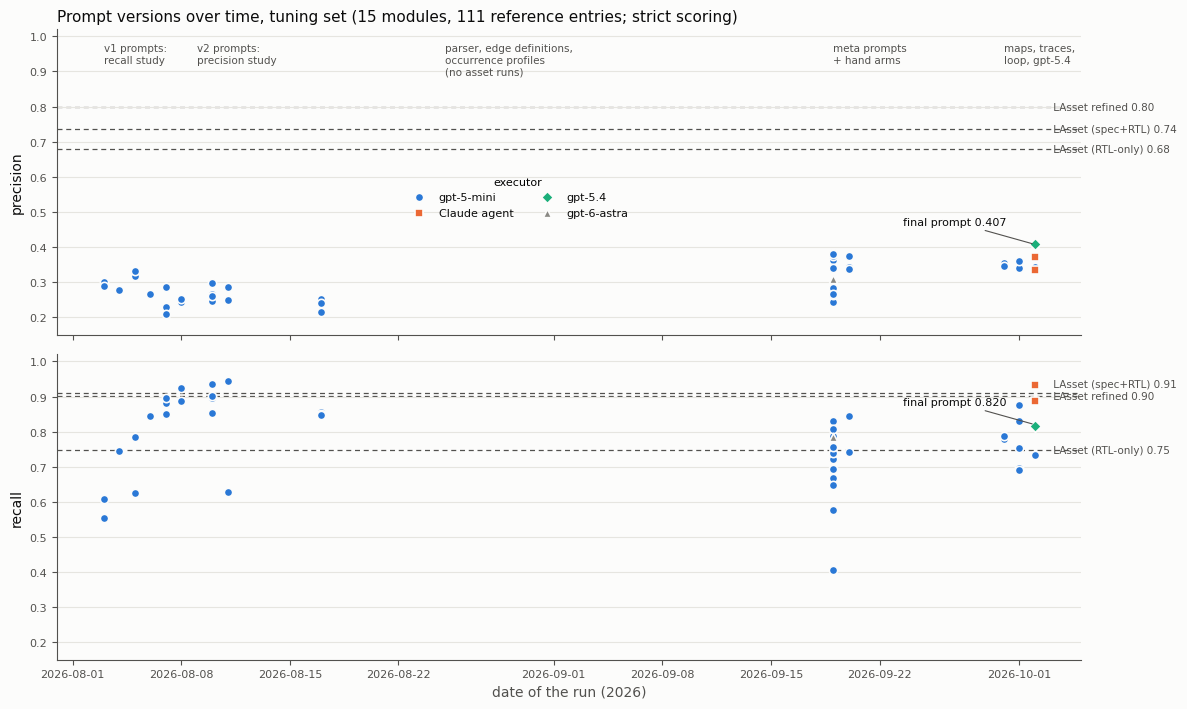

In [24]:
fig, (ax_p, ax_r) = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True, facecolor="#fcfcfb")
plotted = FP.convergence_plot(ax_p, ax_r)
plt.tight_layout(); plt.show()

In [25]:
conv = pd.read_csv("final/convergence.csv")
conv["executor"] = conv["executor"].str.split(" [(]").str[0]
conv["date"] = conv["date"].fillna("").astype(str).str.slice(0, 10)
keep = ["version", "stage", "executor", "date", "runs_complete", "P_mean", "R_mean"]
conv[conv["runs_complete"] > 0][keep].reset_index(drop=True)

,version,stage,executor,date,runs_complete,P_mean,R_mean
0,LAsset initial (RTL-only),0 external reference (LAsset),LAsset pipeline,,1,0.680,0.748
1,LAsset initial (spec+RTL),0 external reference (LAsset),LAsset pipeline,,1,0.737,0.910
2,LAsset refined,0 external reference (LAsset),LAsset pipeline,,1,0.800,0.901
3,v0,"1 recall study, v1 prompts",gpt-5-mini,2026-08-03,3,0.300,0.553
4,v01,"1 recall study, v1 prompts",gpt-5-mini,2026-08-03,3,0.288,0.607
5,v01c2,"1 recall study, v1 prompts",gpt-5-mini,2026-08-04,5,0.277,0.744
6,v01c3,"1 recall study, v1 prompts",gpt-5-mini,2026-08-05,5,0.318,0.784
7,v01r,"1 recall study, v1 prompts",gpt-5-mini,2026-08-05,2,0.331,0.626
8,v01c4,"1 recall study, v1 prompts",gpt-5-mini,2026-08-06,5,0.267,0.845
9,v01c5,"1 recall study, v1 prompts",gpt-5-mini,2026-08-07,5,0.285,0.849


The held-out checks of earlier versions (26 modules, 189 reference entries). The final prompt's held-out row is the
pending generation of section 5.

In [26]:
held = pd.read_csv("final/heldout.csv")
held["executor"] = held["executor"].str.split(" [(]").str[0]
held[["version", "executor", "runs_complete", "P_mean", "R_mean"]]

,version,executor,runs_complete,P_mean,R_mean
0,LAsset initial (RTL-only),LAsset pipeline,1,0.730,0.757
1,LAsset initial (spec+RTL),LAsset pipeline,1,0.734,0.862
2,LAsset refined,LAsset pipeline,1,0.791,0.862
3,m7e194es0ism,gpt-5-mini,3,0.352,0.852
4,blind_D1,claude-opus-5-5,2,0.362,0.619
5,opt_v1,claude-opus-5-5,1,0.329,0.931
6,opt_v0,claude-opus-5-5,1,0.310,0.899


## 11. Limits

- **Held-out generation is pending** (OpenAI credits). The held-out row of section 6 and the transfer test of section
  8 fill in after a run with `RUN_API = True`.
- **One reference.** Every precision figure counts disagreement with one manual list. A false positive here is an
  element the reference does not list; it is not proof that the element is not an asset.
- **LAsset rows are re-scored lists, not reruns.** They are LAsset's published outputs, scored with my strict scorer.
- **The relationship gold was written by an LLM** and adjudicated, on the tuning modules only.
- **The code rules in section 8 are fitted on the reference labels.** They are a diagnostic, not a filter to deploy.
- **Three runs per version.** A difference of a few points between versions can be run-to-run noise; the logs give
  the intervals behind each decision.
- **The map covers direct relationships within one entity.** Values that pass through sub-blocks or process variables
  are traced only as far as the connection.

**Where to go next in the repo:** `README.md` (map of the repo), `docs/TIMELINE.md` (July to October, with decisions),
`ABLATION_LOG.md`, `ABLATION_LOG_V2.md`, `assetgen_meta/prompt_opt/OPTIMIZATION_LOG.md` (the logs), `assetgen_meta.ipynb` (the
ablation notebook), `lasset_step1.ipynb` (occurrence profiles and relation map on the 15 tuning modules),
`lasset_evidence_layer.ipynb` (section 9 in full).